# Anthropic J-lens / J-space and logit-lens comparison

Install `.[jlens,notebooks]`. Fits the ACTUAL Anthropic reference estimator to an actual tiny Hugging Face GPT-2 architecture. The model is randomly initialized and the tokenizer numeric: rankings validate mechanics, not discovered concepts or paper results. `jlens.from_hf` intentionally freezes the supplied model; use a dedicated instance.

Run all cells in a fresh kernel. The final cell records local runtime and kernel RSS.

In [1]:
import os, time, json, resource, sys
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["USE_TF"] = "0"
os.environ["WANDB_MODE"] = "disabled"
import torch, numpy as np
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads")


CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads


jacobian_lens [[3, 29, 0, 18, 31], [4, 28, 25, 12, 6]]
logit_lens [[29, 3, 0, 18, 12], [4, 28, 12, 25, 6]]


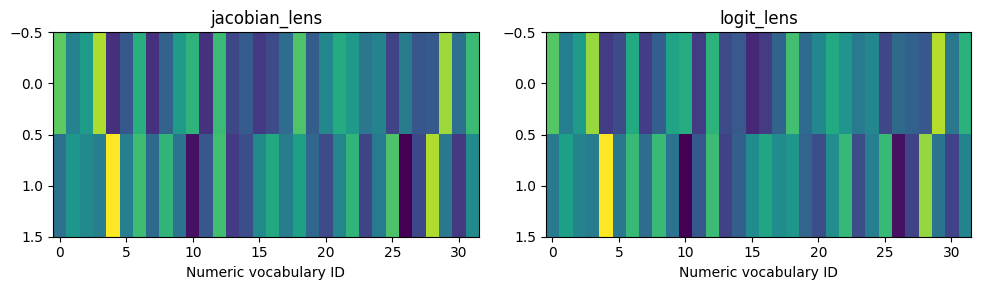

Transport norm: 4.032802104949951


In [2]:
import jlens
import matplotlib.pyplot as plt
from autoexplain.frontier import tiny_hf_causal_lm
from autoexplain.lenses import fit_reference_jlens, read_reference_jlens
model, tokenizer = tiny_hf_causal_lm()
lens_model = jlens.from_hf(model, tokenizer, force_bos=False)
lens = fit_reference_jlens(lens_model, ["1 3 4 5 6", "1 4 3 6 5", "1 6 5 4 3"],
                          source_layers=[0], max_seq_len=16, dim_batch=2)
readouts = read_reference_jlens(lens, lens_model, "1 3 4 5", positions=[1,2])
for kind in ["jacobian_lens", "logit_lens"]:
    print(kind, readouts[kind][0].topk(5, dim=-1).indices.tolist())
fig, axes = plt.subplots(1,2,figsize=(10,3))
for ax, kind in zip(axes, ["jacobian_lens", "logit_lens"]):
    ax.imshow(readouts[kind][0], aspect="auto"); ax.set_title(kind); ax.set_xlabel("Numeric vocabulary ID")
plt.tight_layout(); plt.show()
assert lens.n_prompts == 3
assert all(torch.isfinite(x).all() for x in readouts["jacobian_lens"].values())
print("Transport norm:", lens.jacobians[0].norm().item())


In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib = rss / (1024**2 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                 "kernel_lifetime_peak_rss_mib": round(rss_mib, 2),
                 "memory_scope": "kernel only, including imports; not aggregate system memory"}))


{"tutorial_compute_wall_seconds": 3.018, "kernel_lifetime_peak_rss_mib": 605.35, "memory_scope": "kernel only, including imports; not aggregate system memory"}
